In [3]:
# add parent to path
import sys
from pathlib import Path

sys.path.append("..")

from plots.wandb_utils import get_wandb_stats

runs = [
    # ("i7emr9ga", "Bespoke (flat-storage)"),
    # ("4gbvl510", "Bespoke (bespoke-storage)"),
    ("h1mv9o9r", "Bespoke TPC-H"),  # TPC-H
    # ("wmfzbwa4", "Bespoke TPC-H Flat"),  # TPC-H - flat storage
    ("5qumtphx", "Bespoke CEB"),  # CEB
    # ("nocfw51j", "Bespoke CEB Flat"),  # CEB - flat storage
]


summary_dict = dict()
history_dict = dict()
config_dict = dict()

for id, tag in runs:
    summary, history, config = get_wandb_stats(
        id,
        skip_cache=False,
        wandb_run_cache_path=Path("/mnt/labstore/bespoke_olap/wandb_cache"),
    )
    summary_dict[tag] = summary
    history_dict[tag] = history
    config_dict[tag] = config

# extract benchmark name
benchmarks = [config_dict[tag]["benchmark"] for tag in config_dict.keys()]

benchmark = benchmarks[0]
target_sf_list = []
for benchmark in benchmarks:
    if benchmark == "tpch":
        target_sf = 20
    elif benchmark == "ceb":
        target_sf = 2
    else:
        raise ValueError(f"Unknown benchmark: {benchmark}")

Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/a34a901d2f50cc51db2092712656d83dfe9b6d7757785b785003b489b84435c6.pkl
Loaded wandb data from cache: /mnt/labstore/bespoke_olap/wandb_cache/3c6b188c073e75be45f0039e047104d01e92bf0dc2890ac217df99662b9270d3.pkl


In [4]:
import re

regex = r"validation/query_([0-9a-zA-Z]+)/speedup"

query_ids_by_tag = {}
num_queries_dict = {}
for tag, summary in summary_dict.items():
    query_ids_by_tag[tag] = sorted(
        {re.match(regex, k).group(1) for k in summary.keys() if re.match(regex, k)}
    )
    print(f"{tag}: {len(query_ids_by_tag[tag])} queries")
    num_queries_dict[tag] = len(query_ids_by_tag[tag])


# filter out 8a - it is a heavy outlier (produces 100+x speedup) - it seems duckdb is crazy bad on this query sometimes - but only simetimes...
for tag in query_ids_by_tag:
    if "08a" in query_ids_by_tag[tag]:
        print(f"Removing query 08a from {tag} due to extreme outlier behavior")
        query_ids_by_tag[tag].remove("08a")


Bespoke TPC-H: 22 queries
Bespoke CEB: 16 queries
Removing query 08a from Bespoke CEB due to extreme outlier behavior


In [5]:
import numpy as np

# ---------------------------------------------------------------------------
# Stage configuration
# Entries: (prompt_substring, stage_name)
# ---------------------------------------------------------------------------
STAGES_CONFIG = [
    ("sample execution plan", "w/ Card\nStats. Info"),
    (
        "Focus on the code sections that are the bottlenecks according to the tracing output.",
        "w/ Self-Tracing",
    ),
    ("expert knowledge", "w/ Expert\nKnowledge"),
    (
        "Matthias Jasny",
        "w/ Human-Ref.\nPrompting",
    ),
]

INITIAL_STAGE = "Naive Impl."
STAGES = [INITIAL_STAGE] + [cfg[1] for cfg in STAGES_CONFIG]
TOTAL_SPEEDUP_KEY = "__total_speedup__"


def _get_stage_starts(history, stages_config):
    llm = history[
        (history["type"] == "llm_call") & (history["current_prompt"].notna())
    ][["_step", "current_prompt"]].sort_values("_step")

    starts = []
    for substring, _ in stages_config:
        matched = llm[llm["current_prompt"].str.contains(substring, regex=False)]
        starts.append(int(matched.iloc[0]["_step"]) if len(matched) else None)
    return starts


def geomean(values):
    finite = [v for v in values if np.isfinite(v) and v > 0]
    return np.exp(np.mean(np.log(finite))) if finite else float("nan")


def _total_speedup_from_runtime_rows(rows, query_ids):
    duckdb_total = 0.0
    impl_total = 0.0
    for qid in query_ids:
        duckdb_col = f"validation/query_{qid}/duckdb_runtime_ms"
        impl_col = f"validation/query_{qid}/impl_runtime_ms"
        if duckdb_col not in rows.columns or impl_col not in rows.columns:
            continue
        pairs = rows[[duckdb_col, impl_col]].dropna()
        if pairs.empty:
            continue
        duckdb_ms = float(pairs.iloc[-1][duckdb_col])
        impl_ms = float(pairs.iloc[-1][impl_col])
        if np.isfinite(duckdb_ms) and np.isfinite(impl_ms) and impl_ms > 0:
            duckdb_total += duckdb_ms
            impl_total += impl_ms

    if impl_total <= 0:
        return float("nan")
    return duckdb_total / impl_total


def extract_ablation_speedups(
    history, query_ids, num_total_queries, target_sf, stages_config
):
    stage_names = [cfg[1] for cfg in stages_config]

    val = history[history["type"] == "validate"].copy()

    # only consider stages where all queries for this run have been executed
    if "validation/num_queries" in val.columns:
        val = val[val["validation/num_queries"] == num_total_queries]

    if "validation/scale_factor" in val.columns:
        val = val[val["validation/scale_factor"] == target_sf]
    if "validation/trace_mode" in val.columns:
        val = val[val["validation/trace_mode"] == False]
    val = val.sort_values("_step")

    speedup_cols = [f"validation/query_{qid}/speedup" for qid in query_ids]
    speedup_cols = [c for c in speedup_cols if c in val.columns]

    stage_data = {INITIAL_STAGE: {}}
    stage_totals = {INITIAL_STAGE: float("nan")}
    for name in stage_names:
        stage_data[name] = {}
        stage_totals[name] = float("nan")

    if val.empty or not speedup_cols:
        print("No usable validate rows / speedup columns for ablation extraction.")
        stage_data[TOTAL_SPEEDUP_KEY] = stage_totals
        return stage_data

    # Initial: first full-coverage row, else earliest best-coverage row
    coverage = val[speedup_cols].notna().sum(axis=1)
    if (coverage == len(speedup_cols)).any():
        initial_row = val.loc[(coverage == len(speedup_cols)).idxmax()]
    else:
        initial_row = val.loc[coverage.idxmax()]

    for qid in query_ids:
        col = f"validation/query_{qid}/speedup"

        if col in val.columns:
            tmp = initial_row[col]
            if tmp == "Infinity":
                stage_data[INITIAL_STAGE][qid] = float("inf")
            else:
                stage_data[INITIAL_STAGE][qid] = float(tmp)
    stage_totals[INITIAL_STAGE] = _total_speedup_from_runtime_rows(
        val.loc[[initial_row.name]], query_ids
    )

    # Stage windows: latest available value per query inside each stage window
    stage_starts = _get_stage_starts(history, stages_config)
    print("Stage starts:", dict(zip(stage_names, stage_starts)))

    for i, name in enumerate(stage_names):
        lo = stage_starts[i]
        if lo is None:
            continue

        hi = next(
            (
                stage_starts[j]
                for j in range(i + 1, len(stage_starts))
                if stage_starts[j] is not None
            ),
            int(1e18),
        )
        rows = val[(val["_step"] >= lo) & (val["_step"] < hi)]
        if rows.empty:
            continue

        for qid in query_ids:
            col = f"validation/query_{qid}/speedup"
            if col not in rows.columns:
                continue
            series = rows[col].dropna()
            if not series.empty:
                stage_data[name][qid] = float(series.iloc[-1])

        stage_totals[name] = _total_speedup_from_runtime_rows(rows, query_ids)

    stage_data[TOTAL_SPEEDUP_KEY] = stage_totals
    return stage_data


def _target_sf_for_benchmark(benchmark_name):
    if benchmark_name == "tpch":
        return 20
    if benchmark_name == "ceb":
        return 2
    raise ValueError(f"Unknown benchmark: {benchmark_name}")


# Run extraction per series/run
run_info = {}
all_stage_speedups = {}
for tag, hist in history_dict.items():
    benchmark = config_dict[tag]["benchmark"]
    target_sf = _target_sf_for_benchmark(benchmark)
    qids = query_ids_by_tag[tag]
    num_total_queries = num_queries_dict[tag]

    run_info[tag] = {
        "benchmark": benchmark,
        "target_sf": target_sf,
        "query_ids": qids,
    }
    all_stage_speedups[tag] = extract_ablation_speedups(
        hist, qids, num_total_queries, target_sf, STAGES_CONFIG
    )

print("All stage speedups:", all_stage_speedups)


# apply overwrite - avoid inconsistent plots due to noise (measured in other benchmarking runs)
if "Bespoke CEB" in all_stage_speedups:
    all_stage_speedups["Bespoke CEB"]["__total_speedup__"][
        "w/ Human-Ref.\nPrompting"
    ] = 9.74


# Print summary
for tag, stage_data in all_stage_speedups.items():
    print(f"\n{tag}")
    for stage in STAGES:
        vals = [v for v in stage_data.get(stage, {}).values() if np.isfinite(v)]
        if vals:
            print(
                f"  {stage!r:55s}: geomean={geomean(vals):.2f}x  "
                f"avg={np.mean(vals):.2f}x  median={np.median(vals):.2f}x  "
                f"total={stage_data[TOTAL_SPEEDUP_KEY].get(stage, float('nan')):.2f}x  "
                f"n={len(vals)}"
            )
        else:
            print(f"  {stage!r:55s}: (no data)")

Stage starts: {'w/ Card\nStats. Info': 276, 'w/ Self-Tracing': 746, 'w/ Expert\nKnowledge': 2509, 'w/ Human-Ref.\nPrompting': 3221}
Stage starts: {'w/ Card\nStats. Info': 268, 'w/ Self-Tracing': 820, 'w/ Expert\nKnowledge': 2088, 'w/ Human-Ref.\nPrompting': 2865}
All stage speedups: {'Bespoke TPC-H': {'Naive Impl.': {'001': 6.241935651387213, '002': 4.183180835616438, '003': 2.760565564202335, '004': 6.726501198312236, '005': 4.026550629271917, '006': 1.2044562711076685, '007': 1.0685404616399208, '008': 1.8594893876063185, '009': 1.1207012640522107, '010': 4.404952682094081, '011': 3.36657363258786, '012': 3.254311101376721, '013': 3.6973330059171596, '014': 2.541519989892985, '015': 2.758141639468691, '016': 0.6064554180887373, '017': 1.6746587599486524, '018': 6.9097795360465115, '019': 6.918926055590258, '020': 2.138046530040733, '021': 6.260781460396039, '022': 4.836565671353252}, 'w/ Card\nStats. Info': {'001': 7.936448857361963, '002': 5.485728161676647, '003': 3.879888632812499

In [6]:
benchmark_name_dict = {"tpch": "TPC-H", "ceb": "CEB"}

Saved: figures/ablation_study_multi_benchmark_total.pdf


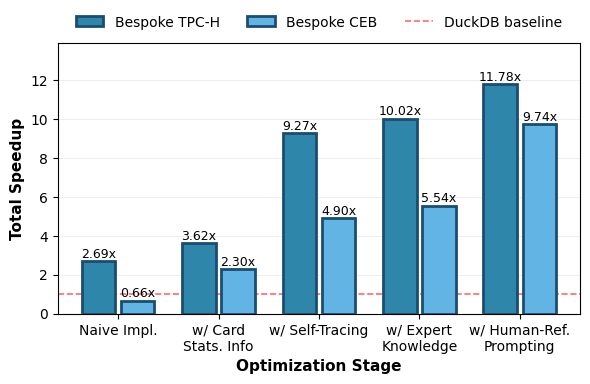

In [15]:
import matplotlib.pyplot as plt

prop_colors = [c["color"] for c in plt.rcParams["axes.prop_cycle"]]
journal_primary_blue = "#2E86AB"
journal_secondary_blue = "#62B4E4"
journal_edge_blue = "#1a4d6f"
journal_accent_red = "#FF6B6B"

run_palette = [journal_primary_blue, journal_secondary_blue] + prop_colors
run_colors = {tag: run_palette[i % len(run_palette)] for i, (_, tag) in enumerate(runs)}

x = np.arange(len(STAGES))
n_runs = len(all_stage_speedups)
group_width = 0.78
slot_width = group_width / max(n_runs, 1)
bar_width = slot_width * 0.86
offsets = (np.arange(n_runs) - (n_runs - 1) / 2) * slot_width

fig, ax = plt.subplots(figsize=(6, 4))

# geometric mean vs standard average toggle
metric = "total"  # median, average, geomean, total
metric_str = {
    "geomean": "Geometric Mean",
    "average": "Average",
    "median": "Median",
    "total": "Total",
}[metric]

all_means = []
for offset, (tag, stage_data) in zip(offsets, all_stage_speedups.items()):
    if metric == "geomean":
        means = [geomean(list(stage_data.get(s, {}).values())) for s in STAGES]
    elif metric == "average":
        means = [np.mean(list(stage_data.get(s, {}).values())) for s in STAGES]
    elif metric == "median":
        means = [np.median(list(stage_data.get(s, {}).values())) for s in STAGES]
    elif metric == "total":
        means = [
            stage_data.get(TOTAL_SPEEDUP_KEY, {}).get(s, float("nan")) for s in STAGES
        ]

    all_means.extend([m for m in means if np.isfinite(m)])

    bars = ax.bar(
        x + offset,
        means,
        bar_width,
        label=tag,
        color=run_colors[tag],
        zorder=3,
        edgecolor=journal_edge_blue,
        linewidth=2.0,
        alpha=1,
    )

    for bar, val in zip(bars, means):
        if np.isfinite(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + 0.03,
                f"{val:.2f}x",
                ha="center",
                va="bottom",
                fontsize=9,
            )

ax.axhline(
    y=1,
    color=journal_accent_red,
    label="DuckDB baseline",
    linestyle="--",
    linewidth=1.2,
    # zorder=1,
)
# ax.text(
#     0.01,
#     1.07,
#     "DuckDB baseline (speedup = 1x)",
#     transform=ax.get_yaxis_transform(),
#     color=journal_accent_red,
#     fontsize=9,
#     ha="left",
#     va="bottom",
# )

ax.set_xlabel("Optimization Stage", fontsize=11, fontweight="bold")
ax.set_ylabel(f"{metric_str} Speedup", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(STAGES, fontsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

if all_means:
    ymax = max(1.25, max(all_means) * 1.18)
else:
    ymax = 1.5
ax.set_ylim(0, ymax)

legend_cols = min(3, len(all_stage_speedups) + 1)
handles, labels = ax.get_legend_handles_labels()
duckdb_idx = next(
    (i for i, lbl in enumerate(labels) if lbl.lower().startswith("duckdb baseline")),
    None,
)
if duckdb_idx is not None:
    handles.append(handles.pop(duckdb_idx))
    labels.append(labels.pop(duckdb_idx))
ax.legend(
    handles,
    labels,
    frameon=False,
    fontsize=10,
    ncols=legend_cols,
    loc="upper right",
    bbox_to_anchor=(0.99, 1.15),
)

plt.tight_layout()

benchmarks_in_plot = sorted({info["benchmark"] for info in run_info.values()})
if len(benchmarks_in_plot) == 1:
    benchmark = benchmarks_in_plot[0]
    target_sf_values = sorted({info["target_sf"] for info in run_info.values()})
    sf_suffix = target_sf_values[0] if len(target_sf_values) == 1 else "multi"
    out_path = f"figures/ablation_study_{benchmark}_sf{sf_suffix}_{metric}.pdf"
else:
    out_path = f"figures/ablation_study_multi_benchmark_{metric}.pdf"

plt.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
print(f"Saved: {out_path}")
plt.show()

Saved: figures/ablation_per_query_Bespoke_TPC-H_tpch_sf20.pdf


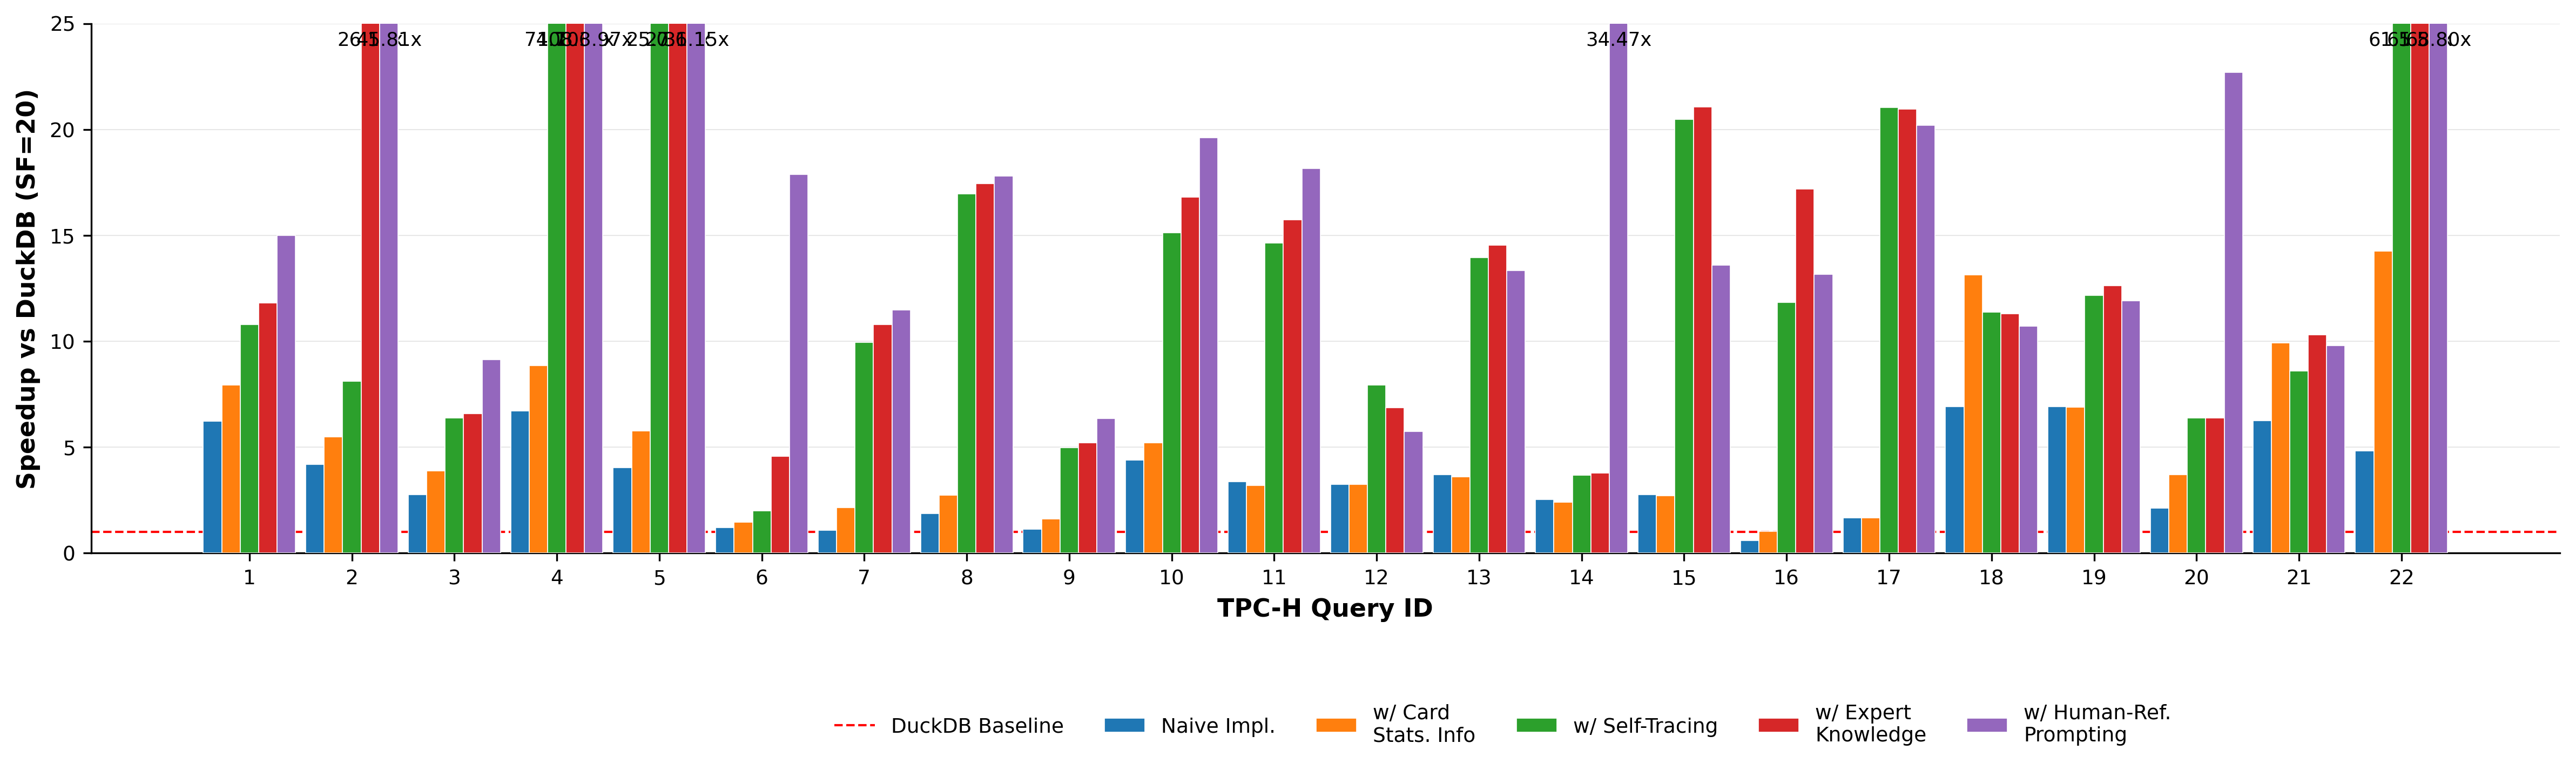

/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/jwehrstein/bespoke_olap/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


Saved: figures/ablation_per_query_Bespoke_CEB_ceb_sf2.pdf


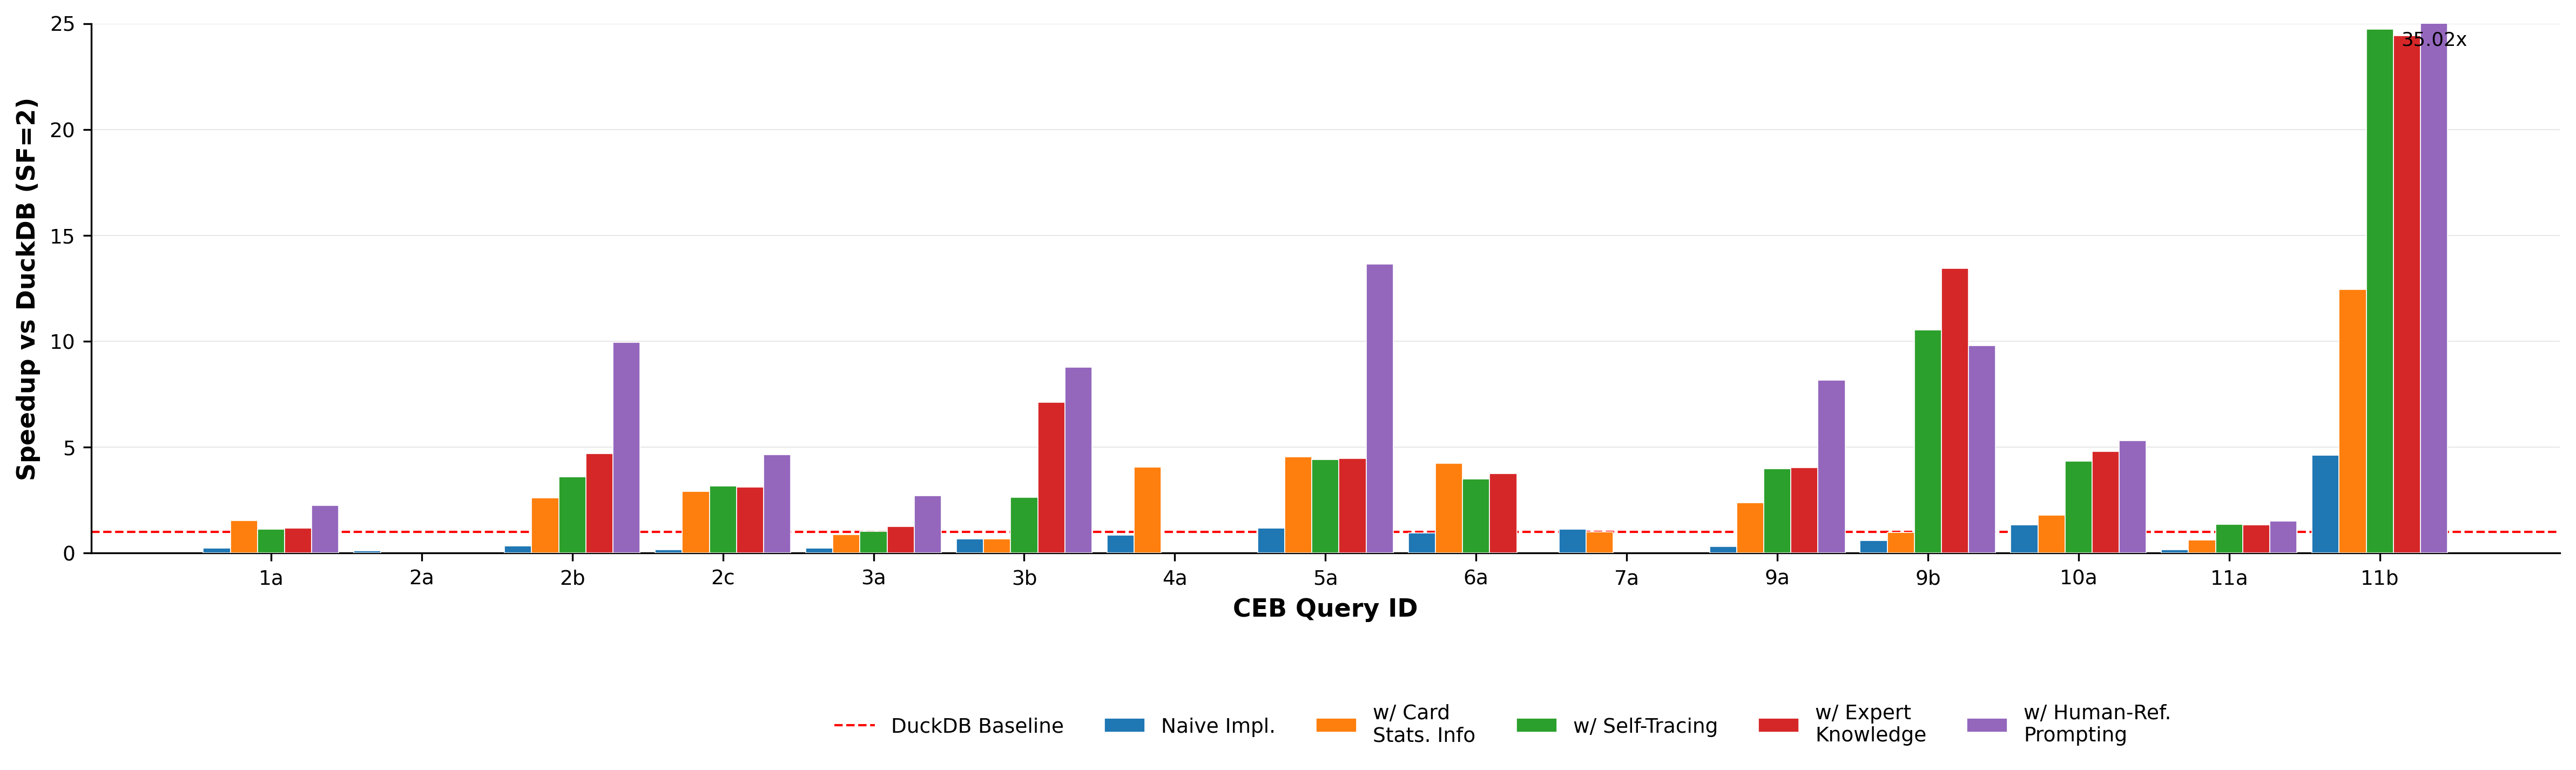

In [8]:
# Per-query breakdown: speedup at each stage as a grouped bar chart

Y_MAX = 25

for tag, stage_data in all_stage_speedups.items():
    benchmark = run_info[tag]["benchmark"]
    target_sf = run_info[tag]["target_sf"]
    query_ids_for_tag = run_info[tag]["query_ids"]
    query_ids_formatted = [qid.lstrip("0") or "0" for qid in query_ids_for_tag]

    fig, ax = plt.subplots(figsize=(16, 5), dpi=300)

    stage_colors = [prop_colors[i] for i in range(len(STAGES))]
    n_stages = len(STAGES)
    x = np.arange(len(query_ids_formatted))
    w = 0.18
    offsets = np.linspace(-(n_stages - 1) / 2, (n_stages - 1) / 2, n_stages) * w

    for offset, stage, color in zip(offsets, STAGES, stage_colors):
        vals = [
            stage_data.get(stage, {}).get(qid, float("nan"))
            for qid in query_ids_for_tag
        ]

        bars = ax.bar(
            x + offset,
            vals,
            w,
            label=stage,
            color=color,
            zorder=3,
            edgecolor="white",
            linewidth=0.4,
        )

        for bar, val in zip(bars, vals):
            if np.isfinite(val) and val > Y_MAX:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    Y_MAX - 0.35,
                    f"{val:.2f}x",
                    ha="center",
                    va="top",
                    fontsize=8.5,
                    fontweight="medium",
                    rotation=0,
                )

    ax.axhline(
        y=1,
        color="red",
        linestyle="--",
        linewidth=1.0,
        label="DuckDB Baseline",
        zorder=2,
    )
    ax.set_xlabel(
        f"{benchmark_name_dict[benchmark]} Query ID", fontsize=11, fontweight="bold"
    )
    ax.set_ylabel(f"Speedup vs DuckDB (SF={target_sf})", fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(query_ids_formatted, rotation=0, ha="center", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.legend(
        frameon=False, ncols=n_stages + 1, bbox_to_anchor=(0.85, -0.25), fontsize=9
    )
    ax.grid(axis="y", alpha=0.3, linestyle="-", linewidth=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, Y_MAX)
    plt.tight_layout()
    out_path = f"figures/ablation_per_query_{tag.replace(' ', '_')}_{benchmark}_sf{target_sf}.pdf"
    plt.savefig(out_path, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

In [9]:
history_dict.keys()

dict_keys(['Bespoke TPC-H', 'Bespoke CEB'])

In [10]:
df = history_dict["Bespoke TPC-H Flat"]


# filter by type=validate
fdf = df[df["type"] == "validate"]
# fdf = fdf[fdf["validation/query_003/speedup"].notna()]
# fdf = fdf[fdf["validation/scale_factor"] == target_sf]
# fdf = fdf[fdf["validation/trace_mode"] == False]

# for c in sorted(list(fdf.columns)):
#     print(c)

# target cols
target_cols = []
for c in fdf.columns:
    if c.startswith("validation/query_"):
        if "003" in c:
            target_cols.append(c)
    elif "all_queries" in c:
        continue
    elif (
        "total" in c
        or c.startswith("compaction/")
        or c.startswith("apply_patch")
        or c.startswith("shell")
    ):
        continue
    elif c in [
        "cached_tokens",
        "reasoning_tokens",
        "tool/handoff_count",
        "agent_name",
        "input_tokens",
        "output_tokens",
        "_runtime",
        "prompt_idx",
        "validation/fasttest_optimize",
        "_step",
        "cost_usd",
        "context_window_usage",
        "turn",
        "current_prompt",
    ]:
        continue
    elif c in [
        "validation/correct",
        "validation/error",
        "validation/scale_factor",
        "type",
        "validation/num_successful_queries",
    ]:
        continue
    else:
        target_cols.append(c)

# convert _timestamp column to readable
import pandas as pd

fdf["_timestamp"] = pd.to_datetime(fdf["_timestamp"], unit="s")

fdf[target_cols]

KeyError: 'Bespoke TPC-H Flat'

In [ ]:
df

,validation/query_014/speedup,reasoning_tokens,validation/num_queries,validation/query_005/impl_runtime_ms,validation/query_006/speedup,context_window_usage,tool/validate_count,validation/query_017/speedup,validation/external_call,_runtime,...,validation/query_008/speedup,validation/query_018/speedup,validation/sf20_all_queries_data,validation/query_017/duckdb_runtime_ms,final/num_prompts,validation/query_006/duckdb_runtime_ms,validation/num_successful_queries,validation/query_010/impl_runtime_ms,current_hash,validation/query_009/impl_runtime_ms
0,2.278698,NaN,22.0,1118.0,0.915756,NaN,1,0.937992,True,8.975628,...,1.052879,2.551851,{'_latest_artifact_path': 'wandb-client-artifa...,2174.26529,NaN,518.317682,22.0,2465.666667,9effe3b638db2d0a04999d0050ffcd58d00ced24,7496.333333
1,NaN,0.0,NaN,NaN,NaN,0.003407,1,NaN,None,8.981468,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,6dd83ef33d4e5de3da955abeff01f3532c37541c,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,None,9.050723,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,6dd83ef33d4e5de3da955abeff01f3532c37541c,NaN
3,NaN,0.0,NaN,NaN,NaN,0.004888,1,NaN,None,9.055352,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,1a34aa07dfcba1810b247fb06142b1fc41cc1f55,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,None,9.120842,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,1a34aa07dfcba1810b247fb06142b1fc41cc1f55,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,NaN,NaN,1.0,NaN,NaN,NaN,699,NaN,True,5439.099691,...,NaN,NaN,None,NaN,NaN,NaN,1.0,NaN,0f33ae63a86afe8b89e34a8d5626c368febd0331,NaN
3247,NaN,0.0,NaN,NaN,NaN,0.003978,699,NaN,None,5458.172911,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,b8deddcd22245097d508d30f4f18a3eaa3f8373c,NaN
3248,NaN,NaN,1.0,NaN,NaN,NaN,700,NaN,True,5484.530709,...,NaN,NaN,None,NaN,NaN,NaN,1.0,NaN,b8deddcd22245097d508d30f4f18a3eaa3f8373c,NaN
3249,NaN,NaN,NaN,NaN,NaN,NaN,700,NaN,None,5575.334226,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,b8deddcd22245097d508d30f4f18a3eaa3f8373c,NaN
